### LOAD LIBRARY

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

### GENERATE DATA

In [32]:
# RANDOM DATA PERTAMA SHAPE TIDAK SESUAI

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(scale=0.1, size=100)

In [33]:
# MENYESUAIKAN SHAPE

x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(x).ravel() + np.random.normal(scale=0.1, size=100)

### CLASS SVQR

In [34]:
class AccurateSVQR(BaseEstimator, RegressorMixin):
    """
    Accurate Support Vector Quantile Regression with Pinball Loss
    
    This implementation uses the correct pinball loss function and 
    a custom solver based on quadratic programming formulation.
    """
    
    def __init__(self, tau=0.5, kernel='rbf', C=1.0, gamma='auto', 
                 epsilon=1e-6, max_iter=1000, tol=1e-6):
        """
        Parameters:
        -----------
        tau : float, default=0.5
            Quantile level (0 < tau < 1)
        kernel : str, default='rbf'
            Kernel type ('linear', 'rbf', 'poly')
        C : float, default=1.0
            Regularization parameter
        gamma : float or 'auto', default='auto'
            Kernel coefficient for RBF kernel
        epsilon : float, default=1e-6
            Precision tolerance
        max_iter : int, default=1000
            Maximum iterations for solver
        tol : float, default=1e-6
            Convergence tolerance
        """
        self.tau = tau
        self.kernel = kernel
        self.C = C
        self.gamma = gamma
        self.epsilon = epsilon
        self.max_iter = max_iter
        self.tol = tol
        
    def _compute_kernel_matrix(self, X1, X2=None):
        """Compute kernel matrix"""
        if X2 is None:
            X2 = X1
            
        if self.kernel == 'linear':
            return np.dot(X1, X2.T)
        elif self.kernel == 'rbf':
            if self.gamma == 'auto':
                gamma = 1.0 / X1.shape[1]
            else:
                gamma = self.gamma
                
            # Efficient RBF kernel computation
            X1_norm = np.sum(X1**2, axis=1).reshape(-1, 1)
            X2_norm = np.sum(X2**2, axis=1).reshape(1, -1)
            distances = X1_norm + X2_norm - 2 * np.dot(X1, X2.T)
            return np.exp(-gamma * np.maximum(distances, 0))
        elif self.kernel == 'poly':
            degree = getattr(self, 'degree', 3)
            return (np.dot(X1, X2.T) + 1) ** degree
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel}")
    
    def _pinball_loss(self, y_true, y_pred):
        """Pinball loss function (quantile loss)"""
        error = y_true - y_pred
        return np.mean(np.maximum(self.tau * error, (self.tau - 1) * error))
    
    def _pinball_loss_derivative(self, error):
        """Derivative of pinball loss"""
        return np.where(error >= 0, -self.tau, self.tau - 1)
    
    def _solve_dual_problem(self, K, y):
        """
        Solve the dual problem for SVQR using quadratic programming approach
        
        The dual problem for SVQR is:
        maximize: sum(y_i * (alpha_i^+ - alpha_i^-)) - 0.5 * sum_ij (alpha_i^+ - alpha_i^-)(alpha_j^+ - alpha_j^-) K_ij
        subject to: 0 <= alpha_i^+ <= C*tau, 0 <= alpha_i^- <= C*(1-tau)
                   sum(alpha_i^+ - alpha_i^-) = 0
        """
        n = len(y)
        
        # Variables: [alpha_plus, alpha_minus]
        # Each of size n, so total 2n variables
        
        def objective(alpha):
            alpha_plus = alpha[:n]
            alpha_minus = alpha[n:]
            alpha_diff = alpha_plus - alpha_minus
            
            # Objective: -[sum(y_i * alpha_diff_i) - 0.5 * alpha_diff^T K alpha_diff]
            linear_term = np.dot(y, alpha_diff)
            quadratic_term = 0.5 * np.dot(alpha_diff, np.dot(K, alpha_diff))
            return -(linear_term - quadratic_term)
        
        def objective_grad(alpha):
            alpha_plus = alpha[:n]
            alpha_minus = alpha[n:]
            alpha_diff = alpha_plus - alpha_minus
            
            grad_diff = -y + np.dot(K, alpha_diff)
            grad = np.zeros(2*n)
            grad[:n] = grad_diff      # gradient w.r.t alpha_plus
            grad[n:] = -grad_diff     # gradient w.r.t alpha_minus
            return grad
        
        # Constraints
        constraints = []
        
        # Sum constraint: sum(alpha_plus - alpha_minus) = 0
        A_eq = np.zeros((1, 2*n))
        A_eq[0, :n] = 1    # alpha_plus coefficients
        A_eq[0, n:] = -1   # alpha_minus coefficients
        b_eq = np.array([0])
        
        constraints.append({
            'type': 'eq',
            'fun': lambda alpha: np.dot(A_eq, alpha) - b_eq,
            'jac': lambda alpha: A_eq
        })
        
        # Bounds: 0 <= alpha_plus <= C*tau, 0 <= alpha_minus <= C*(1-tau)
        bounds = []
        for i in range(n):
            bounds.append((0, self.C * self.tau))        # alpha_plus bounds
        for i in range(n):
            bounds.append((0, self.C * (1 - self.tau)))  # alpha_minus bounds
        
        # Initial guess
        alpha0 = np.zeros(2*n)
        
        # Solve optimization problem
        result = minimize(
            objective, alpha0, method='SLSQP',
            jac=objective_grad, bounds=bounds, constraints=constraints,
            options={'maxiter': self.max_iter, 'ftol': self.tol}
        )
        
        if not result.success:
            print(f"Warning: Optimization did not converge: {result.message}")
        
        alpha_plus = result.x[:n]
        alpha_minus = result.x[n:]
        self.dual_coef_ = alpha_plus - alpha_minus
        
        # Find support vectors (non-zero alphas)
        support_threshold = 1e-6
        self.support_mask_ = (np.abs(self.dual_coef_) > support_threshold)
        self.support_vectors_ = self.X_fit_[self.support_mask_]
        self.support_coef_ = self.dual_coef_[self.support_mask_]
        self.n_support_ = np.sum(self.support_mask_)
        
        return result
    
    def _compute_bias(self, K, y):
        """Compute bias term using KKT conditions"""
        # For SVQR, bias computation is more complex than standard SVR
        # We use support vectors that are not at the bounds
        
        predictions_no_bias = np.dot(K, self.dual_coef_)
        
        # Find support vectors not at bounds for bias computation
        alpha_plus = np.maximum(self.dual_coef_, 0)
        alpha_minus = np.maximum(-self.dual_coef_, 0)
        
        # Support vectors not at upper bounds
        not_at_upper_plus = (alpha_plus < self.C * self.tau - 1e-6) & (alpha_plus > 1e-6)
        not_at_upper_minus = (alpha_minus < self.C * (1 - self.tau) - 1e-6) & (alpha_minus > 1e-6)
        
        bias_candidates = []
        
        if np.any(not_at_upper_plus):
            idx = np.where(not_at_upper_plus)[0]
            for i in idx:
                bias_candidates.append(y[i] - predictions_no_bias[i])
        
        if np.any(not_at_upper_minus):
            idx = np.where(not_at_upper_minus)[0]
            for i in idx:
                bias_candidates.append(y[i] - predictions_no_bias[i])
        
        if bias_candidates:
            self.intercept_ = np.mean(bias_candidates)
        else:
            # Fallback: use median of all residuals
            residuals = y - predictions_no_bias
            self.intercept_ = np.median(residuals)
    
    def fit(self, X, y):
        """Fit the SVQR model"""
        self.X_fit_ = X.copy()
        self.y_fit_ = y.copy()
        
        print(f"Fitting SVQR with tau={self.tau}, C={self.C}, kernel={self.kernel}")
        
        # Compute kernel matrix
        K = self._compute_kernel_matrix(X)
        
        # Solve dual problem
        self._solve_dual_problem(K, y)
        
        # Compute bias
        self._compute_bias(K, y)
        
        print(f"Training completed. Support vectors: {self.n_support_}/{len(y)}")
        
        return self
    
    def predict(self, X):
        """Predict quantile values"""
        if not hasattr(self, 'dual_coef_'):
            raise ValueError("Model not fitted yet")
        
        K = self._compute_kernel_matrix(X, self.X_fit_)
        predictions = np.dot(K, self.dual_coef_) + self.intercept_
        
        return predictions
    
    def score(self, X, y):
        """Score using pinball loss (lower is better)"""
        y_pred = self.predict(X)
        return -self._pinball_loss(y, y_pred)  # Negative because higher score is better

### IMPLEMENTASI SVQR

In [35]:
svqr_model = AccurateSVQR(tau=0.5, C=1.0, kernel='rbf', gamma='auto')
svqr_model.fit(x, y)
    
y_pred = svqr_model.predict(x)
mae = mean_absolute_error(y, y_pred)
pinball_loss = svqr_model._pinball_loss(y, y_pred)
    
print(f"MAE: {mae:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

Fitting SVQR with tau=0.5, C=1.0, kernel=rbf
Training completed. Support vectors: 100/100
MAE: 0.0592
Pinball Loss (τ=0.5): 0.0296


### GAMBAR

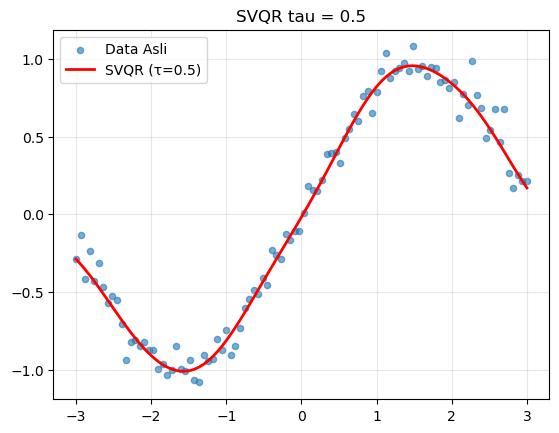

In [36]:
plt.scatter(x, y, alpha=0.6, s=20, label='Data Asli')
plt.plot(x, y_pred, 'r-', linewidth=2, label='SVQR (τ=0.5)')
plt.title('SVQR tau = 0.5')
plt.legend()
plt.grid(True, alpha=0.3)

### DATA BANGKITAN NORMAL INDEPENDEN

In [37]:
import pandas as pd

data1 = pd.read_excel("D:/HASRI/data_svqr1.xlsx")
data2 = pd.read_excel("D:/HASRI/data_svqr2.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'D:/HASRI/data_svqr1.xlsx'

In [ ]:
x1 = data1.iloc[:, 1:30].values
y1 = data1.iloc[:, 0].values

In [ ]:
x2 = data2.iloc[:, 1:30].values
y2 = data2.iloc[:, 0].values

In [ ]:
svqr_bangkitanm = AccurateSVQR(tau=0.5, C=1.0, kernel='rbf', gamma='auto')
svqr_bangkitanm.fit(x1, y1)
    
y_predm = svqr_bangkitanm.predict(x1)
maem = mean_absolute_error(y1, y_predm)
pinball_loss = svqr_bangkitanm._pinball_loss(y1, y_predm)
    
print(f"MAE: {maem:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
svqr_bangkitanmm = AccurateSVQR(tau=0.5, C=1.0, kernel='rbf', gamma='auto')
svqr_bangkitanmm.fit(x2, y2)
    
y_predmm = svqr_bangkitanmm.predict(x2)
maemm = mean_absolute_error(y2, y_predmm)
pinball_loss = svqr_bangkitanmm._pinball_loss(y2, y_predmm)
    
print(f"MAE: {maemm:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
svqr_bangkitan1 = AccurateSVQR(tau=0.01, C=1.0, kernel='rbf', gamma='auto')
svqr_bangkitan1.fit(x1, y1)
    
y_pred1 = svqr_bangkitan1.predict(x1)
mae1 = mean_absolute_error(y1, y_pred1)
pinball_loss = svqr_bangkitan1._pinball_loss(y1, y_pred1)
    
print(f"MAE: {mae1:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
svqr_bangkitan11 = AccurateSVQR(tau=0.01, C=1.0, kernel='rbf', gamma='auto')
svqr_bangkitan11.fit(x2, y2)
    
y_pred11 = svqr_bangkitan11.predict(x2)
mae11 = mean_absolute_error(y2, y_pred11)
pinball_loss = svqr_bangkitan11._pinball_loss(y2, y_pred11)
    
print(f"MAE: {mae11:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
svqr_bangkitan5 = AccurateSVQR(tau=0.05, C=1.0, kernel='rbf', gamma='auto')
svqr_bangkitan5.fit(x1, y1)
    
y_pred5 = svqr_bangkitan5.predict(x1)
mae5 = mean_absolute_error(y1, y_pred5)
pinball_loss = svqr_bangkitan5._pinball_loss(y1, y_pred5)
    
print(f"MAE: {mae5:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
svqr_bangkitan55 = AccurateSVQR(tau=0.05, C=1.0, kernel='rbf', gamma='auto')
svqr_bangkitan55.fit(x2, y2)
    
y_pred55 = svqr_bangkitan55.predict(x2)
mae55 = mean_absolute_error(y2, y_pred55)
pinball_loss = svqr_bangkitan55._pinball_loss(y2, y_pred55)
    
print(f"MAE: {mae55:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
svqr_bangkitan10 = AccurateSVQR(tau=0.1, C=1.0, kernel='rbf', gamma='auto')
svqr_bangkitan10.fit(x1, y1)
    
y_pred10 = svqr_bangkitan10.predict(x1)
mae10 = mean_absolute_error(y1, y_pred10)
pinball_loss = svqr_bangkitan10._pinball_loss(y1, y_pred10)
    
print(f"MAE: {mae10:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
svqr_bangkitan101 = AccurateSVQR(tau=0.1, C=1.0, kernel='rbf', gamma='auto')
svqr_bangkitan101.fit(x2, y2)
    
y_pred101 = svqr_bangkitan101.predict(x2)
mae101 = mean_absolute_error(y2, y_pred101)
pinball_loss = svqr_bangkitan101._pinball_loss(y2, y_pred101)
    
print(f"MAE: {mae101:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
# GABUNGKAN PREDIKSI MENJADI SATU DATA FRAME
data_pred = pd.DataFrame({
    "y1_median": y_predm,
    "y2_median": y_predmm,
    "y1_tau1": y_pred1,
    "y2_tau1": y_pred11,
    "y1_tau5": y_pred5,
    "y2_tau5": y_pred55,
    "y1_tau10": y_pred10,
    "y2_tau10": y_pred101
})

# SAVE EXCEL
data_pred.to_excel("D:/HASRI/prediksi_simulasi(jurnal).xlsx", index=False)

### DATA EMPIRIS

In [ ]:
data_return = pd.read_excel("D:/HASRI/return(jurnal).xlsx")
data_var1 = pd.read_excel("D:/HASRI/VaR_1(jurnal).xlsx")
data_var5 = pd.read_excel("D:/HASRI/VaR_5(jurnal).xlsx")
data_var10 = pd.read_excel("D:/HASRI/VaR_10(jurnal).xlsx")

In [ ]:
x_bbca_1 = data_var1.iloc[:, [1, 2, 3, 4]].values
y_bbca_1 = data_return.iloc[:, 0].reset_index(drop=True)

In [ ]:
svqr_model1 = AccurateSVQR(tau=0.01, C=1.0, kernel='rbf', gamma='auto')
svqr_model1.fit(x_bbca_1, y_bbca_1)
    
y_pred1 = svqr_model1.predict(x_bbca_1)
mae1 = mean_absolute_error(y_bbca_1, y_pred1)
pinball_loss = svqr_model1._pinball_loss(y_bbca_1, y_pred1)
    
print(f"MAE: {mae1:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_bbni_1 = data_var1.iloc[:, [0, 2, 3, 4]].values
y_bbni_1 = data_return.iloc[:, 1].reset_index(drop=True)

In [ ]:
svqr_model2 = AccurateSVQR(tau=0.01, C=1.0, kernel='rbf', gamma='auto')
svqr_model2.fit(x_bbni_1, y_bbni_1)
    
y_pred2 = svqr_model2.predict(x_bbni_1)
mae2 = mean_absolute_error(y_bbni_1, y_pred2)
pinball_loss = svqr_model2._pinball_loss(y_bbni_1, y_pred2)
    
print(f"MAE: {mae2:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_bbri_1 = data_var1.iloc[:, [0, 1, 3, 4]].values
y_bbri_1 = data_return.iloc[:, 2].reset_index(drop=True)

In [ ]:
svqr_model3 = AccurateSVQR(tau=0.01, C=1.0, kernel='rbf', gamma='auto')
svqr_model3.fit(x_bbri_1, y_bbri_1)
    
y_pred3 = svqr_model3.predict(x_bbri_1)
mae3 = mean_absolute_error(y_bbri_1, y_pred3)
pinball_loss = svqr_model3._pinball_loss(y_bbri_1, y_pred3)
    
print(f"MAE: {mae3:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_bmri_1 = data_var1.iloc[:, [0, 1, 2, 4]].values
y_bmri_1 = data_return.iloc[:, 3].reset_index(drop=True)

In [ ]:
svqr_model4 = AccurateSVQR(tau=0.01, C=1.0, kernel='rbf', gamma='auto')
svqr_model4.fit(x_bmri_1, y_bmri_1)
    
y_pred4 = svqr_model4.predict(x_bmri_1)
mae4 = mean_absolute_error(y_bmri_1, y_pred4)
pinball_loss = svqr_model4._pinball_loss(y_bmri_1, y_pred4)
    
print(f"MAE: {mae4:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_arto_1 = data_var1.iloc[:, [0, 1, 2, 3]].values
y_arto_1 = data_return.iloc[:, 4].reset_index(drop=True)

In [ ]:
svqr_model5 = AccurateSVQR(tau=0.01, C=1.0, kernel='rbf', gamma='auto')
svqr_model5.fit(x_arto_1, y_arto_1)
    
y_pred5 = svqr_model5.predict(x_arto_1)
mae5 = mean_absolute_error(y_arto_1, y_pred5)
pinball_loss = svqr_model5._pinball_loss(y_arto_1, y_pred5)
    
print(f"MAE: {mae5:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_bbca_5 = data_var5.iloc[:, [1, 2, 3, 4]].values
y_bbca_5 = data_return.iloc[:, 0].reset_index(drop=True)

In [ ]:
svqr_model6 = AccurateSVQR(tau=0.05, C=1.0, kernel='rbf', gamma='auto')
svqr_model6.fit(x_bbca_5, y_bbca_5)
    
y_pred6 = svqr_model6.predict(x_bbca_5)
mae6 = mean_absolute_error(y_bbca_5, y_pred6)
pinball_loss = svqr_model6._pinball_loss(y_bbca_5, y_pred6)
    
print(f"MAE: {mae6:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_bbni_5 = data_var5.iloc[:, [0, 2, 3, 4]].values
y_bbni_5 = data_return.iloc[:, 1].reset_index(drop=True)

In [ ]:
svqr_model7 = AccurateSVQR(tau=0.05, C=1.0, kernel='rbf', gamma='auto')
svqr_model7.fit(x_bbni_5, y_bbni_5)
    
y_pred7 = svqr_model7.predict(x_bbni_5)
mae7 = mean_absolute_error(y_bbni_5, y_pred7)
pinball_loss = svqr_model7._pinball_loss(y_bbni_5, y_pred7)
    
print(f"MAE: {mae7:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_bbri_5 = data_var5.iloc[:, [0, 1, 3, 4]].values
y_bbri_5 = data_return.iloc[:, 2].reset_index(drop=True)

In [ ]:
svqr_model8 = AccurateSVQR(tau=0.05, C=1.0, kernel='rbf', gamma='auto')
svqr_model8.fit(x_bbri_5, y_bbri_5)
    
y_pred8 = svqr_model8.predict(x_bbri_5)
mae8 = mean_absolute_error(y_bbri_5, y_pred8)
pinball_loss = svqr_model8._pinball_loss(y_bbri_5, y_pred8)
    
print(f"MAE: {mae8:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_bmri_5 = data_var5.iloc[:, [0, 1, 2, 4]].values
y_bmri_5 = data_return.iloc[:, 3].reset_index(drop=True)

In [ ]:
svqr_model9 = AccurateSVQR(tau=0.05, C=1.0, kernel='rbf', gamma='auto')
svqr_model9.fit(x_bmri_5, y_bmri_5)
    
y_pred9 = svqr_model9.predict(x_bmri_5)
mae9 = mean_absolute_error(y_bmri_5, y_pred9)
pinball_loss = svqr_model9._pinball_loss(y_bmri_5, y_pred9)
    
print(f"MAE: {mae9:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_arto_5 = data_var5.iloc[:, [0, 1, 2, 3]].values
y_arto_5 = data_return.iloc[:, 4].reset_index(drop=True)

In [ ]:
svqr_model10 = AccurateSVQR(tau=0.05, C=1.0, kernel='rbf', gamma='auto')
svqr_model10.fit(x_arto_5, y_arto_5)
    
y_pred10 = svqr_model10.predict(x_arto_5)
mae10 = mean_absolute_error(y_arto_5, y_pred10)
pinball_loss = svqr_model10._pinball_loss(y_arto_5, y_pred10)
    
print(f"MAE: {mae10:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_bbca_10 = data_var10.iloc[:, [1, 2, 3, 4]].values
y_bbca_10 = data_return.iloc[:, 0].reset_index(drop=True)

In [ ]:
svqr_model11 = AccurateSVQR(tau=0.10, C=1.0, kernel='rbf', gamma='auto')
svqr_model11.fit(x_bbca_10, y_bbca_10)
    
y_pred11 = svqr_model11.predict(x_bbca_10)
mae11 = mean_absolute_error(y_bbca_10, y_pred11)
pinball_loss = svqr_model11._pinball_loss(y_bbca_10, y_pred11)
    
print(f"MAE: {mae11:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_bbni_10 = data_var10.iloc[:, [0, 2, 3, 4]].values
y_bbni_10 = data_return.iloc[:,1].reset_index(drop=True)

In [ ]:
svqr_model12 = AccurateSVQR(tau=0.10, C=1.0, kernel='rbf', gamma='auto')
svqr_model12.fit(x_bbni_10, y_bbni_10)
    
y_pred12 = svqr_model12.predict(x_bbni_10)
mae12 = mean_absolute_error(y_bbni_10, y_pred12)
pinball_loss = svqr_model12._pinball_loss(y_bbni_10, y_pred12)
    
print(f"MAE: {mae12:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_bbri_10 = data_var10.iloc[:, [0, 1, 3, 4]].values
y_bbri_10 = data_return.iloc[:,2].reset_index(drop=True)

In [ ]:
svqr_model13 = AccurateSVQR(tau=0.10, C=1.0, kernel='rbf', gamma='auto')
svqr_model13.fit(x_bbri_10, y_bbri_10)
    
y_pred13 = svqr_model13.predict(x_bbri_10)
mae13 = mean_absolute_error(y_bbri_10, y_pred13)
pinball_loss = svqr_model13._pinball_loss(y_bbri_10, y_pred13)
    
print(f"MAE: {mae13:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_bmri_10 = data_var10.iloc[:, [0, 1, 2, 4]].values
y_bmri_10 = data_return.iloc[:,3].reset_index(drop=True)

In [ ]:
svqr_model14 = AccurateSVQR(tau=0.10, C=1.0, kernel='rbf', gamma='auto')
svqr_model14.fit(x_bmri_10, y_bmri_10)
    
y_pred14 = svqr_model14.predict(x_bmri_10)
mae14 = mean_absolute_error(y_bmri_10, y_pred14)
pinball_loss = svqr_model14._pinball_loss(y_bmri_10, y_pred14)
    
print(f"MAE: {mae14:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
x_arto_10 = data_var10.iloc[:, [0, 1, 2, 3]].values
y_arto_10 = data_return.iloc[:,4].reset_index(drop=True)

In [ ]:
svqr_model15 = AccurateSVQR(tau=0.10, C=1.0, kernel='rbf', gamma='auto')
svqr_model15.fit(x_arto_10, y_arto_10)
    
y_pred15 = svqr_model15.predict(x_arto_10)
mae15 = mean_absolute_error(y_arto_10, y_pred15)
pinball_loss = svqr_model15._pinball_loss(y_arto_10, y_pred15)
    
print(f"MAE: {mae15:.4f}")
print(f"Pinball Loss (τ=0.5): {pinball_loss:.4f}")

In [ ]:
# GABUNGKAN PREDIKSI MENJADI SATU DATA FRAME
empiris_pred = pd.DataFrame({
    "bbca_1": y_pred1,
    "bbni_1": y_pred2,
    "bbri_1": y_pred3,
    "bmri_1": y_pred4,
    "arto_1": y_pred5,
    "bbca_5": y_pred6,
    "bbni_5": y_pred7,
    "bbri_5": y_pred8,
    "bmri_5": y_pred9,
    "arto_5": y_pred10,
    "bbca_10": y_pred11,
    "bbni_10": y_pred12,
    "bbri_10": y_pred13,
    "bmri_10": y_pred14,
    "arto_10": y_pred15
})

# SAVE EXCEL
empiris_pred.to_excel("D:/HASRI/prediksi_empiris(jurnal).xlsx", index=False)